# 01 — Occlusion audit (Week 1, Gate 1)

**Question:** on broadcast tracking, how many final-third defensive phases can we trust enough to compute VSD on?

All logic lives in `src/`; this notebook only runs it and draws. Thresholds come from `config.yaml`.

Checks performed:
1. **§2.3 string reconciliation** — do the values the aggregators filter on exist in the data?
2. **§3.3 event ↔ tracking alignment** — are event coordinates in the same frame as normalised tracking?
3. **Frame filters** (§5) per frame, and **phase survival** (≥60% of frames passing) for eligible phases.
4. **Sensitivity** of the survival rate to the two occlusion thresholds.
5. **Where** defenders go undetected (heatmap).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from src.config import load_config
from src.audit.run_audit import run
from src.audit.occlusion import survival_sensitivity
from src.viz.field import plot_detection_heatmap, plot_phase_survival, plot_sensitivity

pd.set_option("display.width", 160)
cfg = load_config(ROOT / "config.yaml")
FIG = ROOT / "outputs" / "figures";
FIG.mkdir(parents=True, exist_ok=True)

In [2]:
res = run(cfg=cfg)  # loops every match in matches_dir, one in RAM at a time
res.summary(cfg)

1874553: 127 eligible phases, 25% survive (1.4s)
1886347: 105 eligible phases, 40% survive (1.2s)
1899585: 115 eligible phases, 34% survive (1.2s)
1925299: 108 eligible phases, 41% survive (1.8s)
1927964: 107 eligible phases, 37% survive (1.3s)
1953632: 84 eligible phases, 46% survive (1.2s)
1959846: 128 eligible phases, 31% survive (1.2s)
1986691: 101 eligible phases, 45% survive (1.2s)
1996435: 118 eligible phases, 46% survive (1.2s)
1996436: 99 eligible phases, 46% survive (1.1s)
2006229: 95 eligible phases, 46% survive (1.4s)
2006363: 121 eligible phases, 22% survive (1.5s)
2007448: 107 eligible phases, 31% survive (1.1s)
2007721: 121 eligible phases, 44% survive (1.4s)
2010085: 96 eligible phases, 27% survive (1.2s)
2011166: 111 eligible phases, 34% survive (1.2s)
2013725: 106 eligible phases, 25% survive (2.1s)
2015213: 98 eligible phases, 35% survive (1.3s)
2016236: 109 eligible phases, 17% survive (1.3s)
2017461: 115 eligible phases, 22% survive (1.1s)


,value
matches,20
in-phase frames,630971
possession disagreement (in-phase frames),0.157796
frames ≥ detection floor,0.619499
frames with danger zone visible,0.264071
frames passing all filters,0.197508
mean detected outfield defenders,6.898368
eligible final-third defensive phases,2171
phases surviving,746
phase survival rate,0.34362


## 1 · §2.3 — string values the aggregators rely on
Empty `missing_in_data` everywhere ⇒ `DynamicEventAggregator` contexts are safe to use as-is.

In [3]:
res.strings.assign(found=res.strings.found.map(len)).groupby("column")[["missing_in_data", "unexpected_in_data"]].agg(
    lambda s: sorted({v for l in s for v in l}))

,missing_in_data,unexpected_in_data
column,,
event_type,[],[]
furthest_line_break,[],[]
team_out_of_possession_phase_type,[],[]
third_end,[],[]


## 2 · §3.3 — event ↔ tracking alignment
Median distance (m) between a `player_possession` event's start and the carrier's tracked position at `frame_start`. Sub-metre on both lines ⇒ events are already in metres **and** already direction-normalised.

In [4]:
res.alignment.round(2)

,match_id,n_raw,median_err_raw_m,p90_err_raw_m,n_norm,median_err_norm_m,p90_err_norm_m
0,1874553,500,0.00,0.00,500,0.00,0.00
1,1886347,499,0.13,0.32,499,0.13,0.36
2,1899585,499,0.08,0.25,499,0.08,0.28
3,1925299,497,0.16,0.41,497,0.16,0.44
4,1927964,500,0.00,0.00,500,0.00,0.00
5,1953632,495,0.14,0.32,495,0.15,0.32
6,1959846,500,0.00,0.00,500,0.00,0.00
7,1986691,500,0.00,0.00,500,0.00,0.00
8,1996435,499,0.17,0.43,499,0.17,0.47
9,1996436,500,0.00,0.00,500,0.00,0.00


## 3 · Phase survival

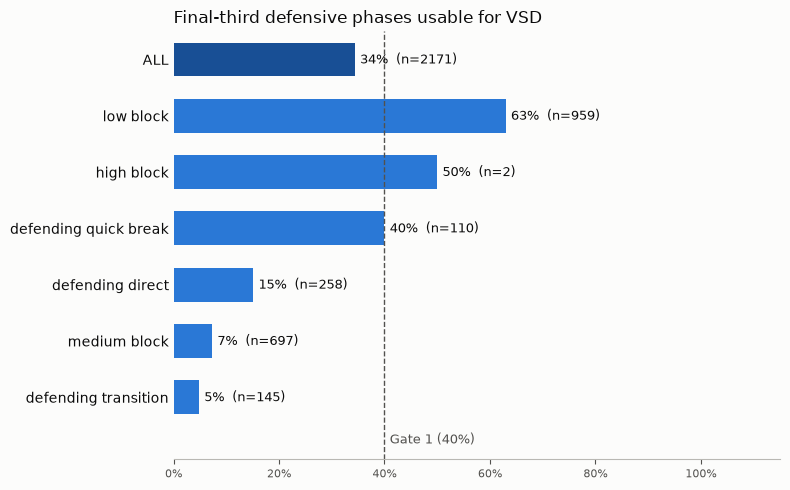

In [5]:
fig = plot_phase_survival(res.phases, cfg["gate1"]["min_phase_survival"],
                          "Final-third defensive phases usable for VSD")
fig.savefig(FIG / "01_phase_survival.png", dpi=200, bbox_inches="tight")

In [6]:
rate_cols = [c for c in res.phases.columns if c.startswith("rate_f_")]
res.phases.groupby("team_out_of_possession_phase_type")[rate_cols + ["frame_pass_rate"]].mean().round(2)

,rate_f_in_phase,rate_f_possession_consistent,rate_f_detection,rate_f_ball,rate_f_ball_detected,rate_f_visible,rate_f_phase_type,frame_pass_rate
team_out_of_possession_phase_type,,,,,,,,
defending_direct,1.00,0.88,0.67,0.99,0.92,0.36,1.00,0.24
defending_quick_break,1.00,0.69,0.71,1.00,0.98,0.63,1.00,0.48
defending_transition,1.00,0.75,0.56,1.00,0.97,0.33,1.00,0.17
high_block,0.97,0.46,0.79,0.96,0.75,0.41,0.97,0.41
low_block,1.00,0.84,0.82,1.00,0.97,0.76,1.00,0.65
medium_block,1.00,0.84,0.66,0.98,0.94,0.20,1.00,0.15


## 4 · Sensitivity — the Gate-1 number across thresholds

vis_min,0.00,0.25,0.50,0.75
det_floor,,,,
5,0.92,0.60,0.41,0.08
6,0.85,0.56,0.39,0.08
7,0.70,0.50,0.34,0.07
8,0.50,0.38,0.27,0.06
9,0.28,0.22,0.16,0.04


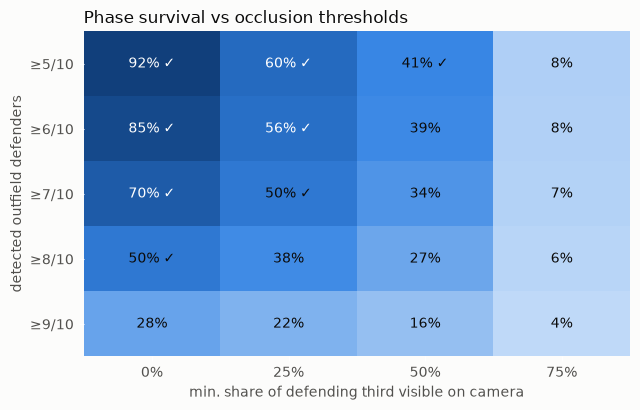

In [7]:
grid = survival_sensitivity(res.frames, res.phases, cfg)
fig = plot_sensitivity(grid, cfg["gate1"]["min_phase_survival"], "Phase survival vs occlusion thresholds")
fig.savefig(FIG / "01_sensitivity.png", dpi=200, bbox_inches="tight")
grid.round(2)

### Why visibility binds: the camera follows the ball

In [8]:
f = res.frames[res.frames.in_phase].copy()
f["ball_third"] = pd.cut(f.ball_x, [-60, -17.5, 17.5, 60], labels=["own third", "middle", "final third"])
f.groupby("ball_third", observed=True).agg(
    frames=("frame", "size"),
    danger_zone_visible=("danger_vis_frac", "mean"),
    frames_visible=("f_visible", "mean"),
    detected_defenders=("n_det_outfield_def", "mean")).round(2)

,frames,danger_zone_visible,frames_visible,detected_defenders
ball_third,,,,
own third,175415,0.00,0.00,5.28
middle,280425,0.21,0.15,7.54
final third,164538,0.60,0.75,7.97


## 5 · Where defenders go undetected

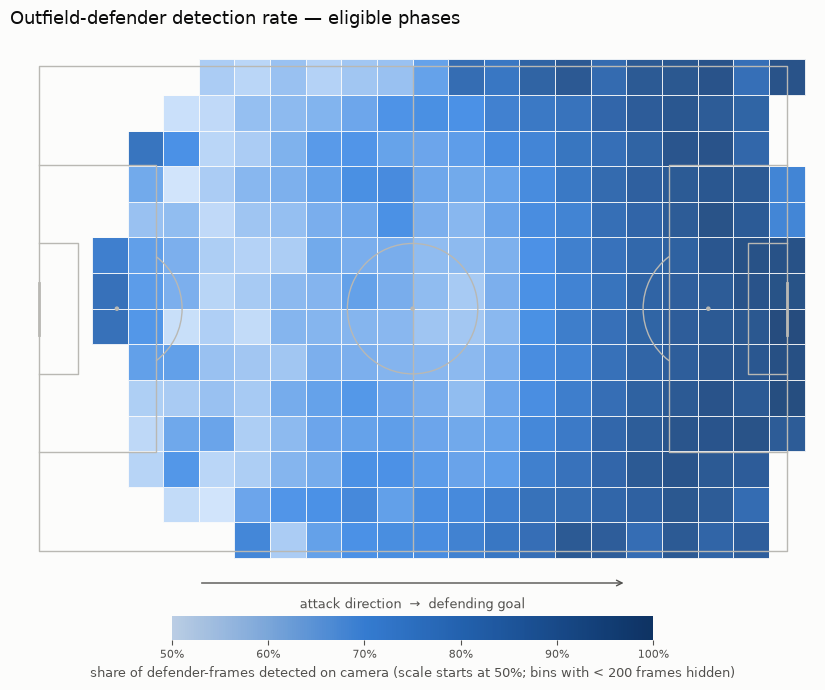

In [9]:
fig = plot_detection_heatmap(res.heat_def, "Outfield-defender detection rate — eligible phases")
fig.savefig(FIG / "01_detection_heatmap.png", dpi=200, bbox_inches="tight")

In [10]:
r = res.roles.groupby("role")[["n", "n_det"]].sum()
(r.n_det / r.n).sort_values().rename("detection_rate").round(2).to_frame().T

role,GK,RF,CF,AM,RWB,LF,RB,CB,LW,RW,LCB,RCB,LB,LWB,LDM,RDM,LM,RM,DM
detection_rate,0.36,0.53,0.59,0.72,0.72,0.74,0.75,0.76,0.76,0.76,0.76,0.77,0.77,0.78,0.87,0.88,0.88,0.89,0.9
